In [1]:
import pandas as pd

df = pd.read_csv(r'C:\Users\Public\Documents\Axel\wcup26\data\clean_fotmob_match_stats.csv')
df.tail()

,teamId,teamName,matches,avg_xG,total_xG,avg_xG_open_play,avg_xG_set_play,avg_xG_non_penalty,mean_ball_possession,fouls,...,touches_opp_box,offsides,tackles_won,interceptions,blocks,clearances,keeper_saves,duel_won,yellow_cards,red_cards
43,5902,Qatar,3,0.530000,1.59,0.453333,0.076667,0.530000,33.000000,675,...,25,4,43,25,28,116,12,98,4,2
44,287981,Curacao,3,0.470000,1.41,0.336667,0.133333,0.470000,32.333333,736,...,40,5,50,39,12,74,20,147,7,0
45,7795,Saudi Arabia,3,0.396667,1.19,0.190000,0.206667,0.396667,38.333333,889,...,32,3,55,33,13,103,16,133,6,0
46,6724,Paraguay,3,0.366667,1.10,0.200000,0.170000,0.366667,33.666667,658,...,30,4,70,27,19,105,13,182,7,1
47,6719,Tunisia,3,0.316667,0.95,0.110000,0.206667,0.316667,39.333333,775,...,29,9,56,28,13,71,6,127,1,0


In [2]:
df.columns

Index(['teamId', 'teamName', 'matches', 'avg_xG', 'total_xG',
       'avg_xG_open_play', 'avg_xG_set_play', 'avg_xG_non_penalty',
       'mean_ball_possession', 'fouls', 'accurate_passes',
       'accurate_long_passes', 'accurate_crosses', 'ground_duels_won',
       'aerial_won', 'dribbles_succeeded', 'goals', 'big_chances',
       'big_chances_missed', 'corners', 'total_shots', 'shots_off_target',
       'blocked_shots', 'hit_woodwork', 'shots_inside_box',
       'shots_outside_box', 'passes', 'own_half_passes',
       'opposition_half_passes', 'throws', 'touches_opp_box', 'offsides',
       'tackles_won', 'interceptions', 'blocks', 'clearances', 'keeper_saves',
       'duel_won', 'yellow_cards', 'red_cards'],
      dtype='str')

In [4]:
df[['teamName', 'goals', 'avg_xG', 'total_xG']].sort_values(by='goals', ascending=False).head()

,teamName,goals,avg_xG,total_xG
0,Germany,9,3.025,6.05
1,Canada,7,2.925,5.85
3,Norway,7,2.360,4.72
11,Netherlands,7,1.695,3.39
14,Portugal,6,1.530,3.06


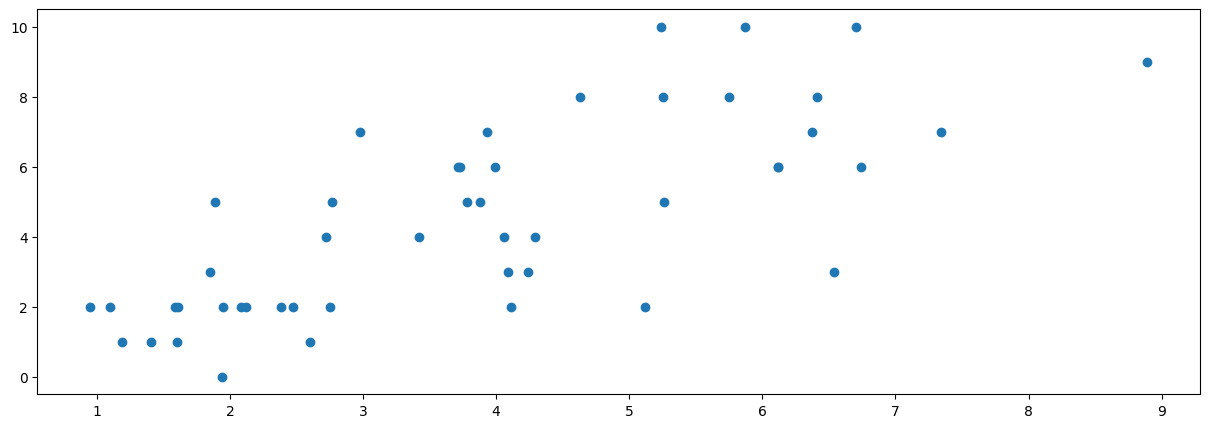

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))
plt.scatter(x=df.total_xG, y=df.goals)

In [3]:
# top 10 avg teams for viz
ten_avg_xG = df[['teamName', 'avg_xG', 'total_xG', 'goals']].sort_values(by='total_xG', ascending=False).head(10)
ten_avg_xG

,teamName,avg_xG,total_xG,goals
0,Germany,3.025,6.05,9
1,Canada,2.925,5.85,7
2,Switzerland,2.630,5.26,5
3,Norway,2.360,4.72,7
4,England,2.280,4.56,4
5,France,2.280,4.56,6
6,Spain,2.200,4.40,4
7,Uruguay,2.020,4.04,3
8,Ecuador,1.925,3.85,0
9,Argentina,1.810,3.62,5


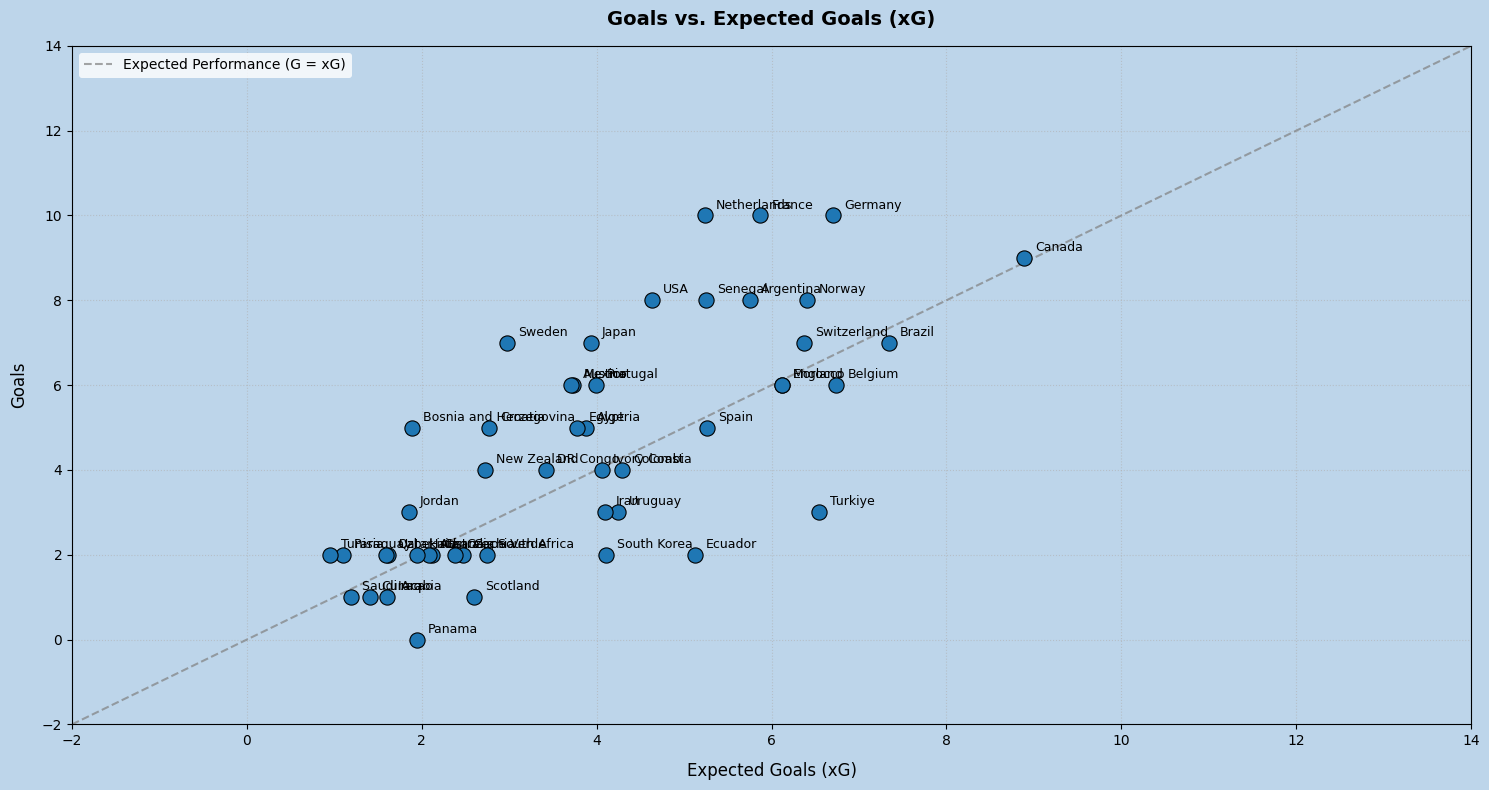

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Initialize the plot
plt.figure(figsize=(15, 8), dpi=100, facecolor="#BDD5EA")

ax = plt.gca()
ax.set_facecolor("#BDD5EA") 

# 2. Dynamic axis limit calculation to keep the chart perfectly square, it compares the two values and returns the max/min of the two
max_val = max(max(df.goals), max(df.total_xG)) + 4
min_val = min(min(df.goals), min(df.total_xG)) - 2

# 3. Draw a line on the chart(Where Goals == xG)
plt.plot(
    [min_val, max_val],
    [min_val, max_val], 
    color='gray', 
    linestyle='--', 
    alpha=0.7, 
    linewidth=1.5,
    label='Expected Performance (G = xG)'
)

# 4. Plot the team data points
plt.scatter(
    df.total_xG,
    df.goals,
    color='#1f77b4', 
    s=120, 
    edgecolors='black', 
    linewidths=0.8, 
    zorder=5
)

# 5. Annotate each data point with the team's name
for i, name in enumerate(df.teamName):
    plt.annotate(
        name, 
        (df.total_xG[i], df.goals[i]), 
        xytext=(8, 5), # Offsets the text slightly up and right
        textcoords='offset points', 
        fontsize=9,
        fontweight='medium'
    )

# 7. Labels, Title, and Formatting
plt.xlabel('Expected Goals (xG)', fontsize=12, labelpad=10)
plt.ylabel('Goals', fontsize=12, labelpad=10)
plt.title('Goals vs. Expected Goals (xG)', fontsize=14, fontweight='bold', pad=15)

# Ensure the plot is a perfect square visually to maintain line geometry
plt.xlim(min_val, max_val)
plt.ylim(min_val, max_val)
plt.gca()
# plt.gca().set_aspect('equal', adjustable='box')

# Add subtle layout helpers
plt.grid(True, linestyle=':', alpha=0.6, zorder=1)
plt.legend(loc='upper left', frameon=True, facecolor='white', edgecolor='none')

# 8. Render the visualization
plt.tight_layout()

# save imgC:\Users\Public\Documents\Axel\wcup26\data\clean_fotmob_match_stats.csv
# plt.savefig(r'C:\Users\Public\Documents\Axel\images\xG_Goals.png', dpi=300, bbox_inches='tight', pad_inches=0.35)

plt.show()

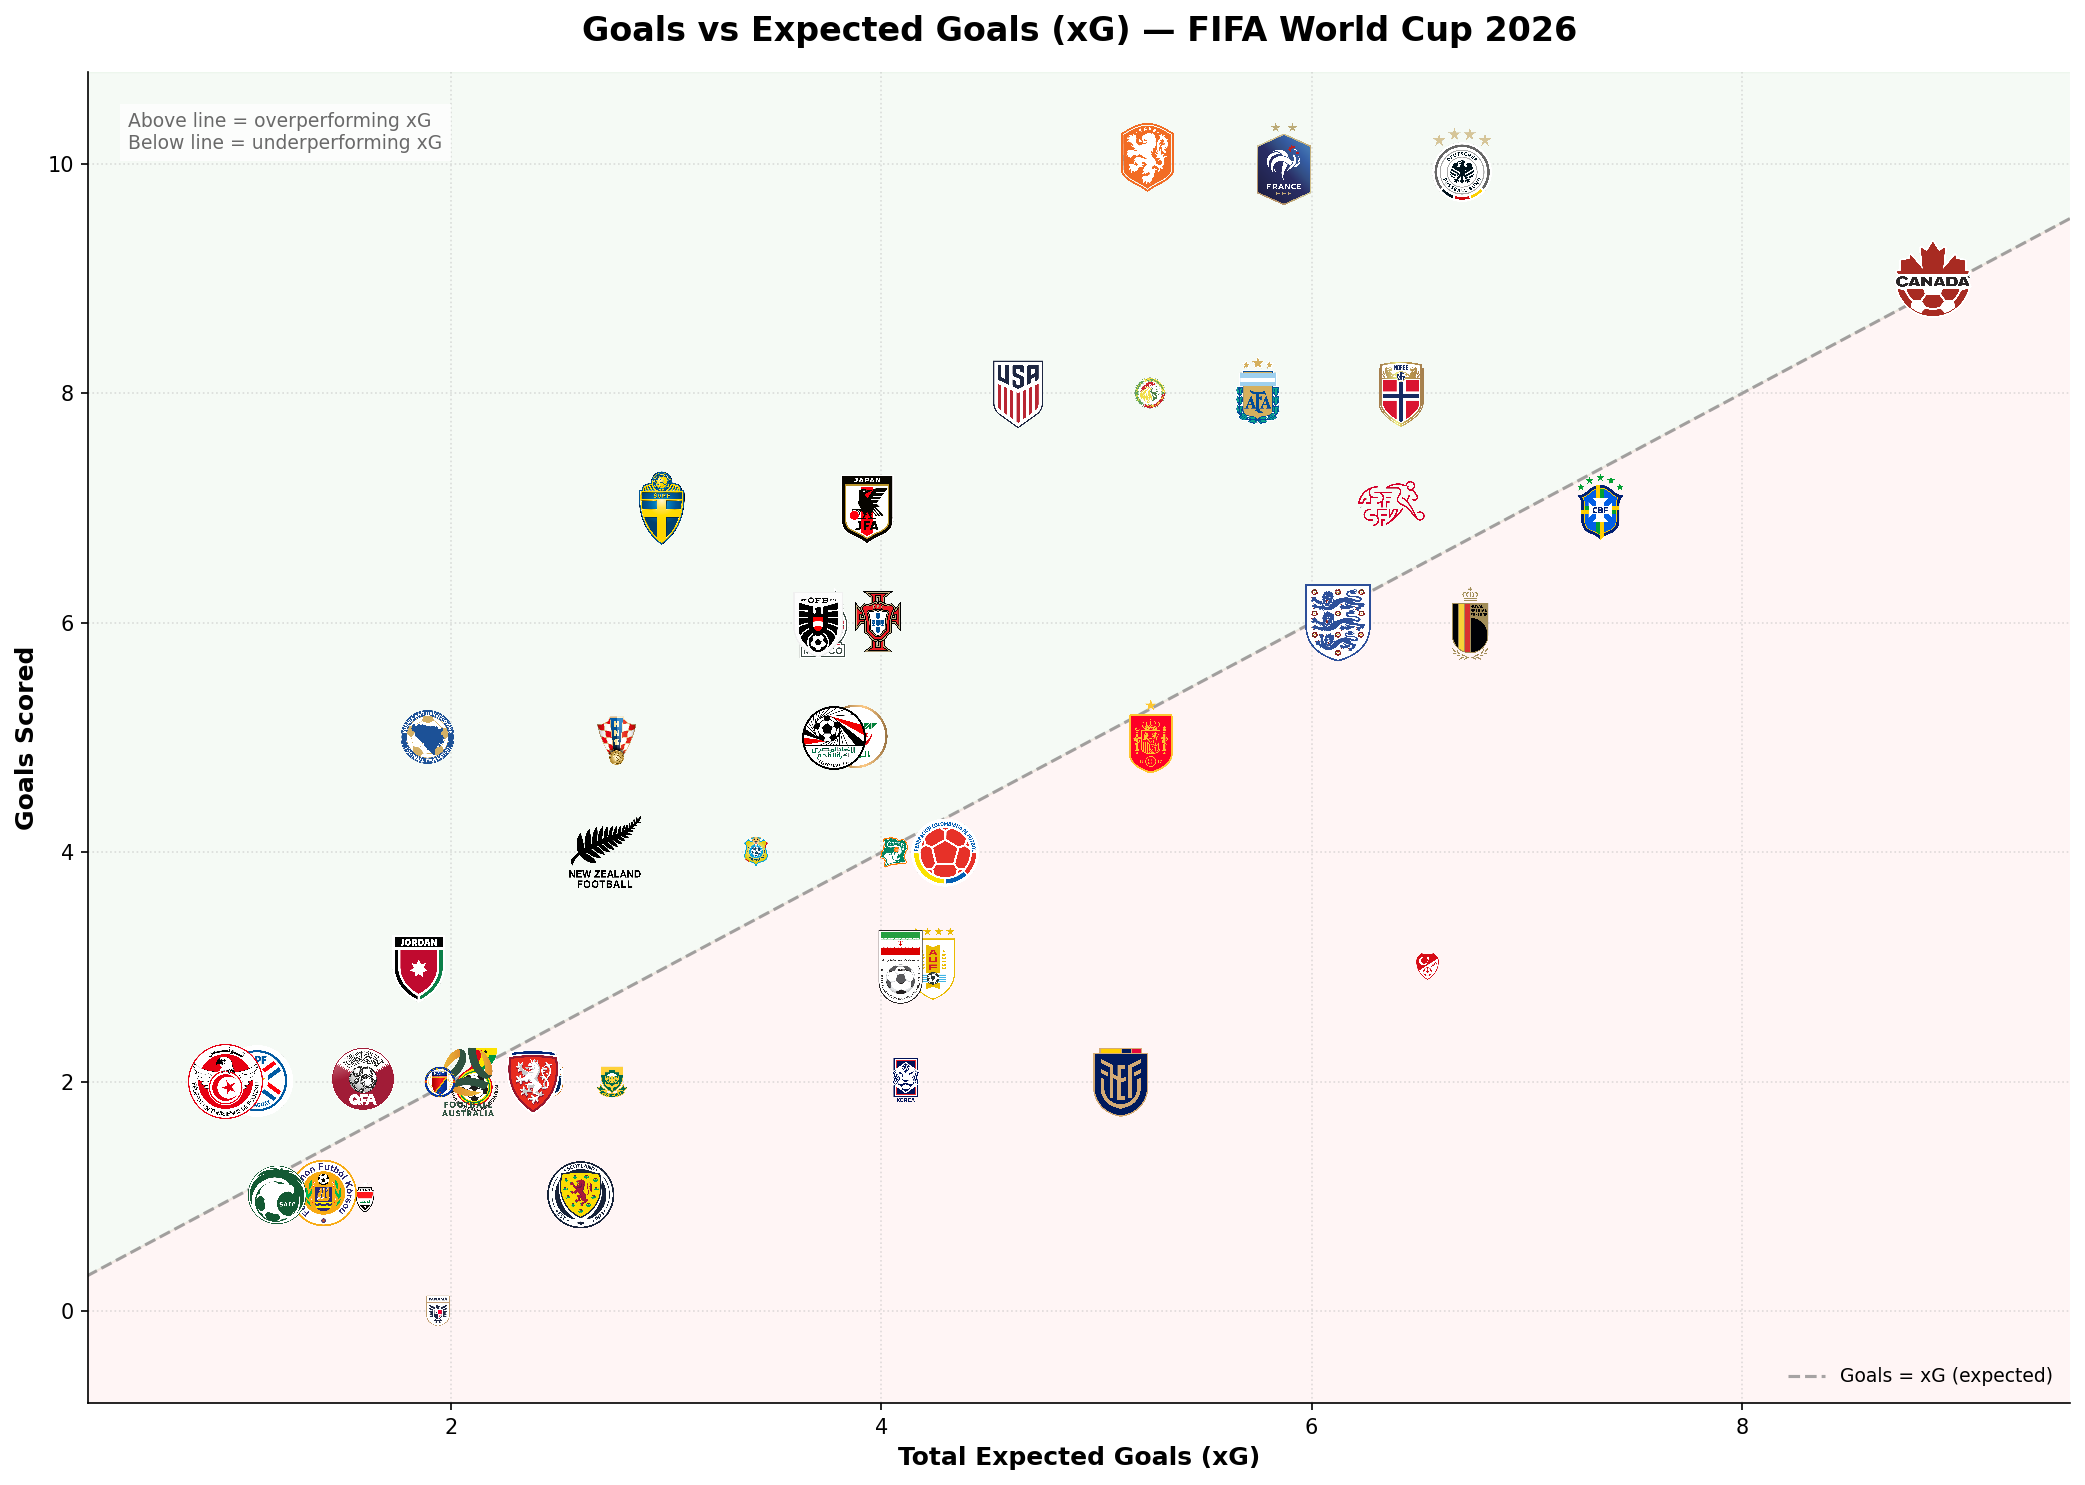

In [5]:
# Claude Matplotlib with team logos https://claude.ai/chat/50421c8d-d5ca-4a39-b6ec-0df23783800f

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import os
import numpy as np

# --- Config ---
logo_folder = r"C:\Users\Public\Documents\Axel\team_logos"  # folder where team logos live
logo_zoom = 0.03        # adjust based on your image resolution
fig, ax = plt.subplots(figsize=(14, 10), dpi=150)

# --- Compute axis limits with padding so logos don't get clipped ---
x = df['total_xG']
y = df['goals']
pad_x = (x.max() - x.min()) * 0.08
pad_y = (y.max() - y.min()) * 0.08
x_min, x_max = x.min() - pad_x, x.max() + pad_x
y_min, y_max = y.min() - pad_y, y.max() + pad_y

# --- Diagonal reference line (goals == xG) ---
lims = [min(x_min, y_min), max(x_max, y_max)]
ax.plot(lims, lims, linestyle='--', color='gray', linewidth=1.5, alpha=0.7, zorder=1, label='Goals = xG (expected)')

# --- Plot each team's logo at (total_xG, goals) ---
def get_logo(team_id, zoom=logo_zoom):
    path = os.path.join(logo_folder, f"{team_id}.png")
    img = mpimg.imread(path)
    return OffsetImage(img, zoom=zoom)

for _, row in df.iterrows():
    try:
        ab = AnnotationBbox(
            get_logo(row['teamId']),
            (row['total_xG'], row['goals']),
            frameon=False,
            zorder=3
        )
        ax.add_artist(ab)
    except FileNotFoundError:
        # fallback: plot a labeled dot if logo missing
        ax.scatter(row['total_xG'], row['goals'], color='green', s=20, zorder=3)
        ax.annotate(row['teamName'], (row['total_xG'], row['goals']), fontsize=6)

# --- Shaded regions to show over/under performance ---
ax.fill_between(lims, lims, y_max, color='green', alpha=0.04, zorder=0)  # overperforming (goals > xG)
ax.fill_between(lims, y_min, lims, color='red', alpha=0.04, zorder=0)    # underperforming

# --- Labels, title, styling ---
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
ax.set_xlabel('Total Expected Goals (xG)', fontsize=12, fontweight='bold')
ax.set_ylabel('Goals Scored', fontsize=12, fontweight='bold')
ax.set_title('Goals vs Expected Goals (xG) — FIFA World Cup 2026', fontsize=16, fontweight='bold', pad=15)
ax.text(0.02, 0.97, 'Above line = overperforming xG\nBelow line = underperforming xG',
        transform=ax.transAxes, fontsize=9, va='top', color='dimgray',
        bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(True, linestyle=':', alpha=0.4)
ax.legend(loc='lower right', fontsize=9, frameon=False)

plt.tight_layout()
# save img
# plt.savefig(r'C:\Users\Public\Documents\Axel\images\xG_Goals_diagonal.png', dpi=300, bbox_inches='tight', pad_inches=0.35)
plt.show()

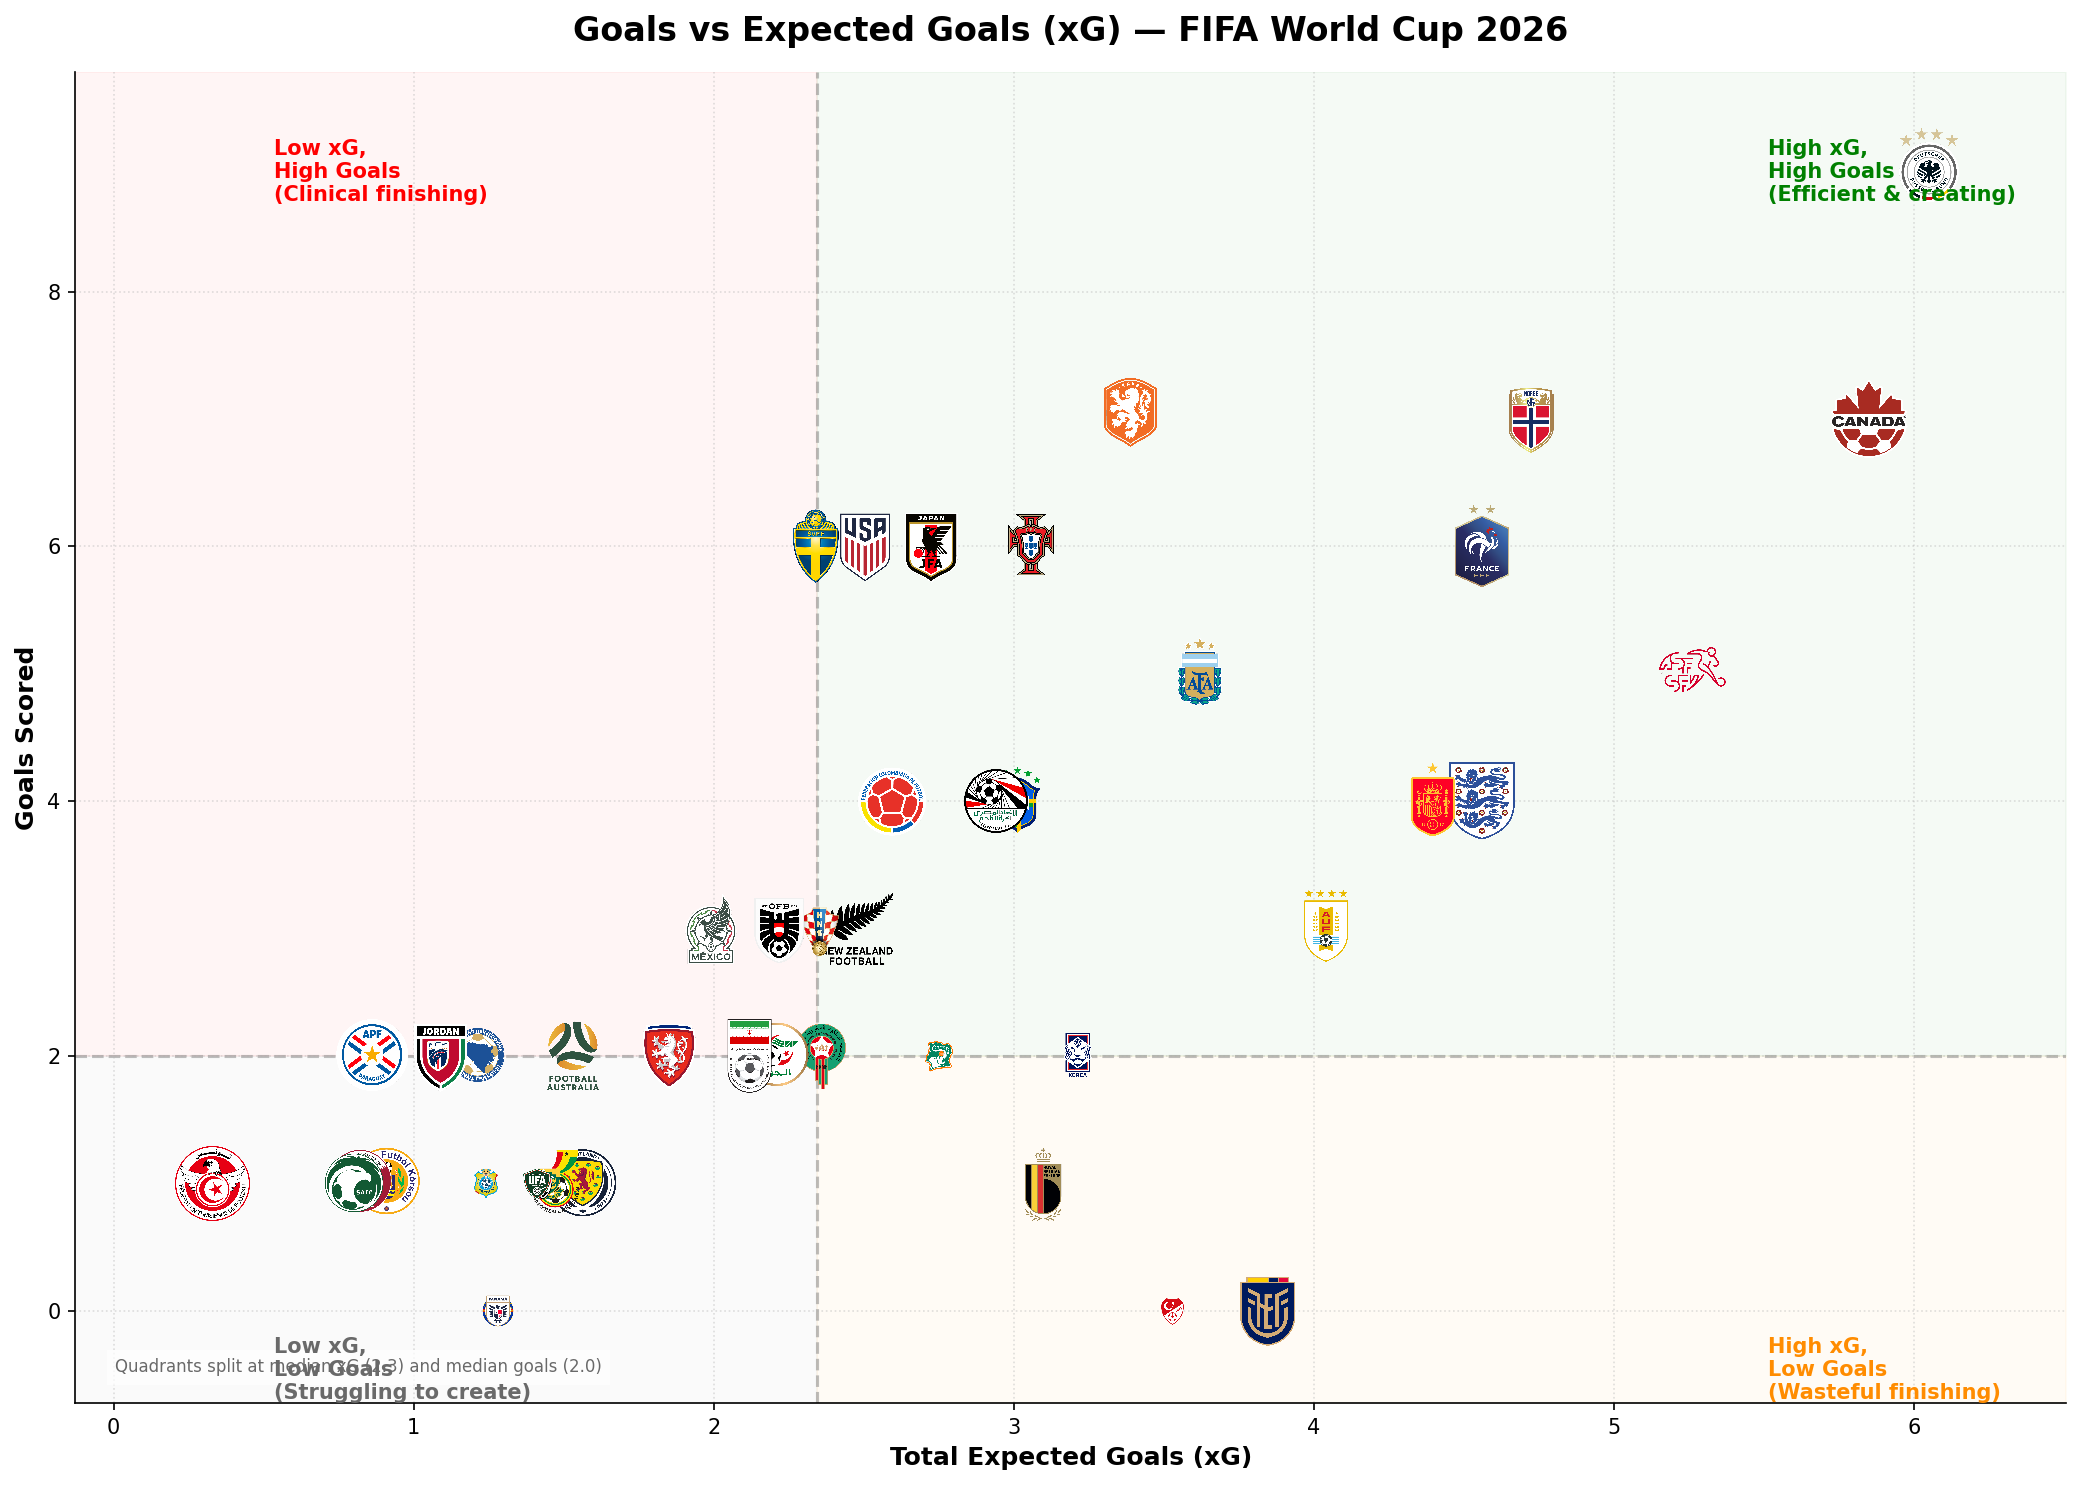

In [7]:
# Quadrant https://claude.ai/chat/f575dd0a-bf62-4c59-9733-3894467a9001

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import os
import numpy as np

# --- Config ---
logo_folder = r"C:\Users\Public\Documents\Axel\team_logos"
logo_zoom = 0.03
annotation_size = 10
fig, ax = plt.subplots(figsize=(14, 10), dpi=150)

# --- Compute axis limits with padding so logos don't get clipped ---
x = df['total_xG']
y = df['goals']
pad_x = (x.max() - x.min()) * 0.08
pad_y = (y.max() - y.min()) * 0.08
x_min, x_max = x.min() - pad_x, x.max() + pad_x
y_min, y_max = y.min() - pad_y, y.max() + pad_y

# --- Quadrant lines (median-based instead of diagonal) ---
median_xg = x.median()
median_goals = y.median()
ax.axvline(median_xg, linestyle='--', color='gray', linewidth=1.5, alpha=0.5, zorder=1)
ax.axhline(median_goals, linestyle='--', color='gray', linewidth=1.5, alpha=0.5, zorder=1)

# --- Plot each team's logo ---
def get_logo(team_id, zoom=logo_zoom):
    path = os.path.join(logo_folder, f"{team_id}.png")
    img = mpimg.imread(path)
    return OffsetImage(img, zoom=zoom)

for _, row in df.iterrows():
    try:
        ab = AnnotationBbox(
            get_logo(row['teamId']),
            (row['total_xG'], row['goals']),
            frameon=False,
            zorder=3
        )
        ax.add_artist(ab)
    except FileNotFoundError:
        ax.scatter(row['total_xG'], row['goals'], color='green', s=20, zorder=3)
        ax.annotate(row['teamName'], (row['total_xG'], row['goals']), fontsize=6)

# --- Quadrant background shading (optional, light tint per quadrant) ---
ax.fill_between(x=[x_min, median_xg], y1=median_goals, y2=y_max, color='red', alpha=0.04, zorder=0)     # low xG, high goals
ax.fill_between([median_xg, x_max], median_goals, y_max, color='green', alpha=0.04, zorder=0)   # high xG, high goals
ax.fill_between([x_min, median_xg], y_min, median_goals, color='gray', alpha=0.04, zorder=0)     # low xG, low goals
ax.fill_between([median_xg, x_max], y_min, median_goals, color='orange', alpha=0.04, zorder=0)   # high xG, low goals

# --- Quadrant annotations ---
x_range = x_max - x_min
y_range = y_max - y_min

annotations = [
    dict(x=x_min + x_range*0.1, y=y_max - y_range*0.05,
         text="Low xG,\nHigh Goals\n(Clinical finishing)",
         color="red"),
    dict(x=x_max - x_range*0.15, y=y_max - y_range*0.05,
         text="High xG,\nHigh Goals\n(Efficient & creating)",
         color="green"),
    dict(x=x_min + x_range*0.1, y=y_min + y_range*0.05,
         text="Low xG,\nLow Goals\n(Struggling to create)",
         color="dimgray"),
    dict(x=x_max - x_range*0.15, y=y_min + y_range*0.05,
         text="High xG,\nLow Goals\n(Wasteful finishing)",
         color="darkorange"),
]

for ann in annotations:
    ax.text(ann['x'], ann['y'], ann['text'],
            fontsize=annotation_size, fontweight='bold',
            color=ann['color'], ha='left', va='top',
            zorder=4)

# --- Labels, title, styling ---
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
ax.set_xlabel('Total Expected Goals (xG)', fontsize=12, fontweight='bold')
ax.set_ylabel('Goals Scored', fontsize=12, fontweight='bold')
ax.set_title('Goals vs Expected Goals (xG) — FIFA World Cup 2026', fontsize=16, fontweight='bold', pad=15)
ax.text(0.02, 0.02, f'Quadrants split at median xG ({median_xg:.1f}) and median goals ({median_goals:.1f})',
        transform=ax.transAxes, fontsize=8, va='bottom', color='dimgray',
        bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(True, linestyle=':', alpha=0.4)

plt.tight_layout()
# plt.savefig(r'C:\Users\Public\Documents\Axel\images\xG_Goals_quadrant.png', dpi=300, bbox_inches='tight', pad_inches=0.35)
plt.show()

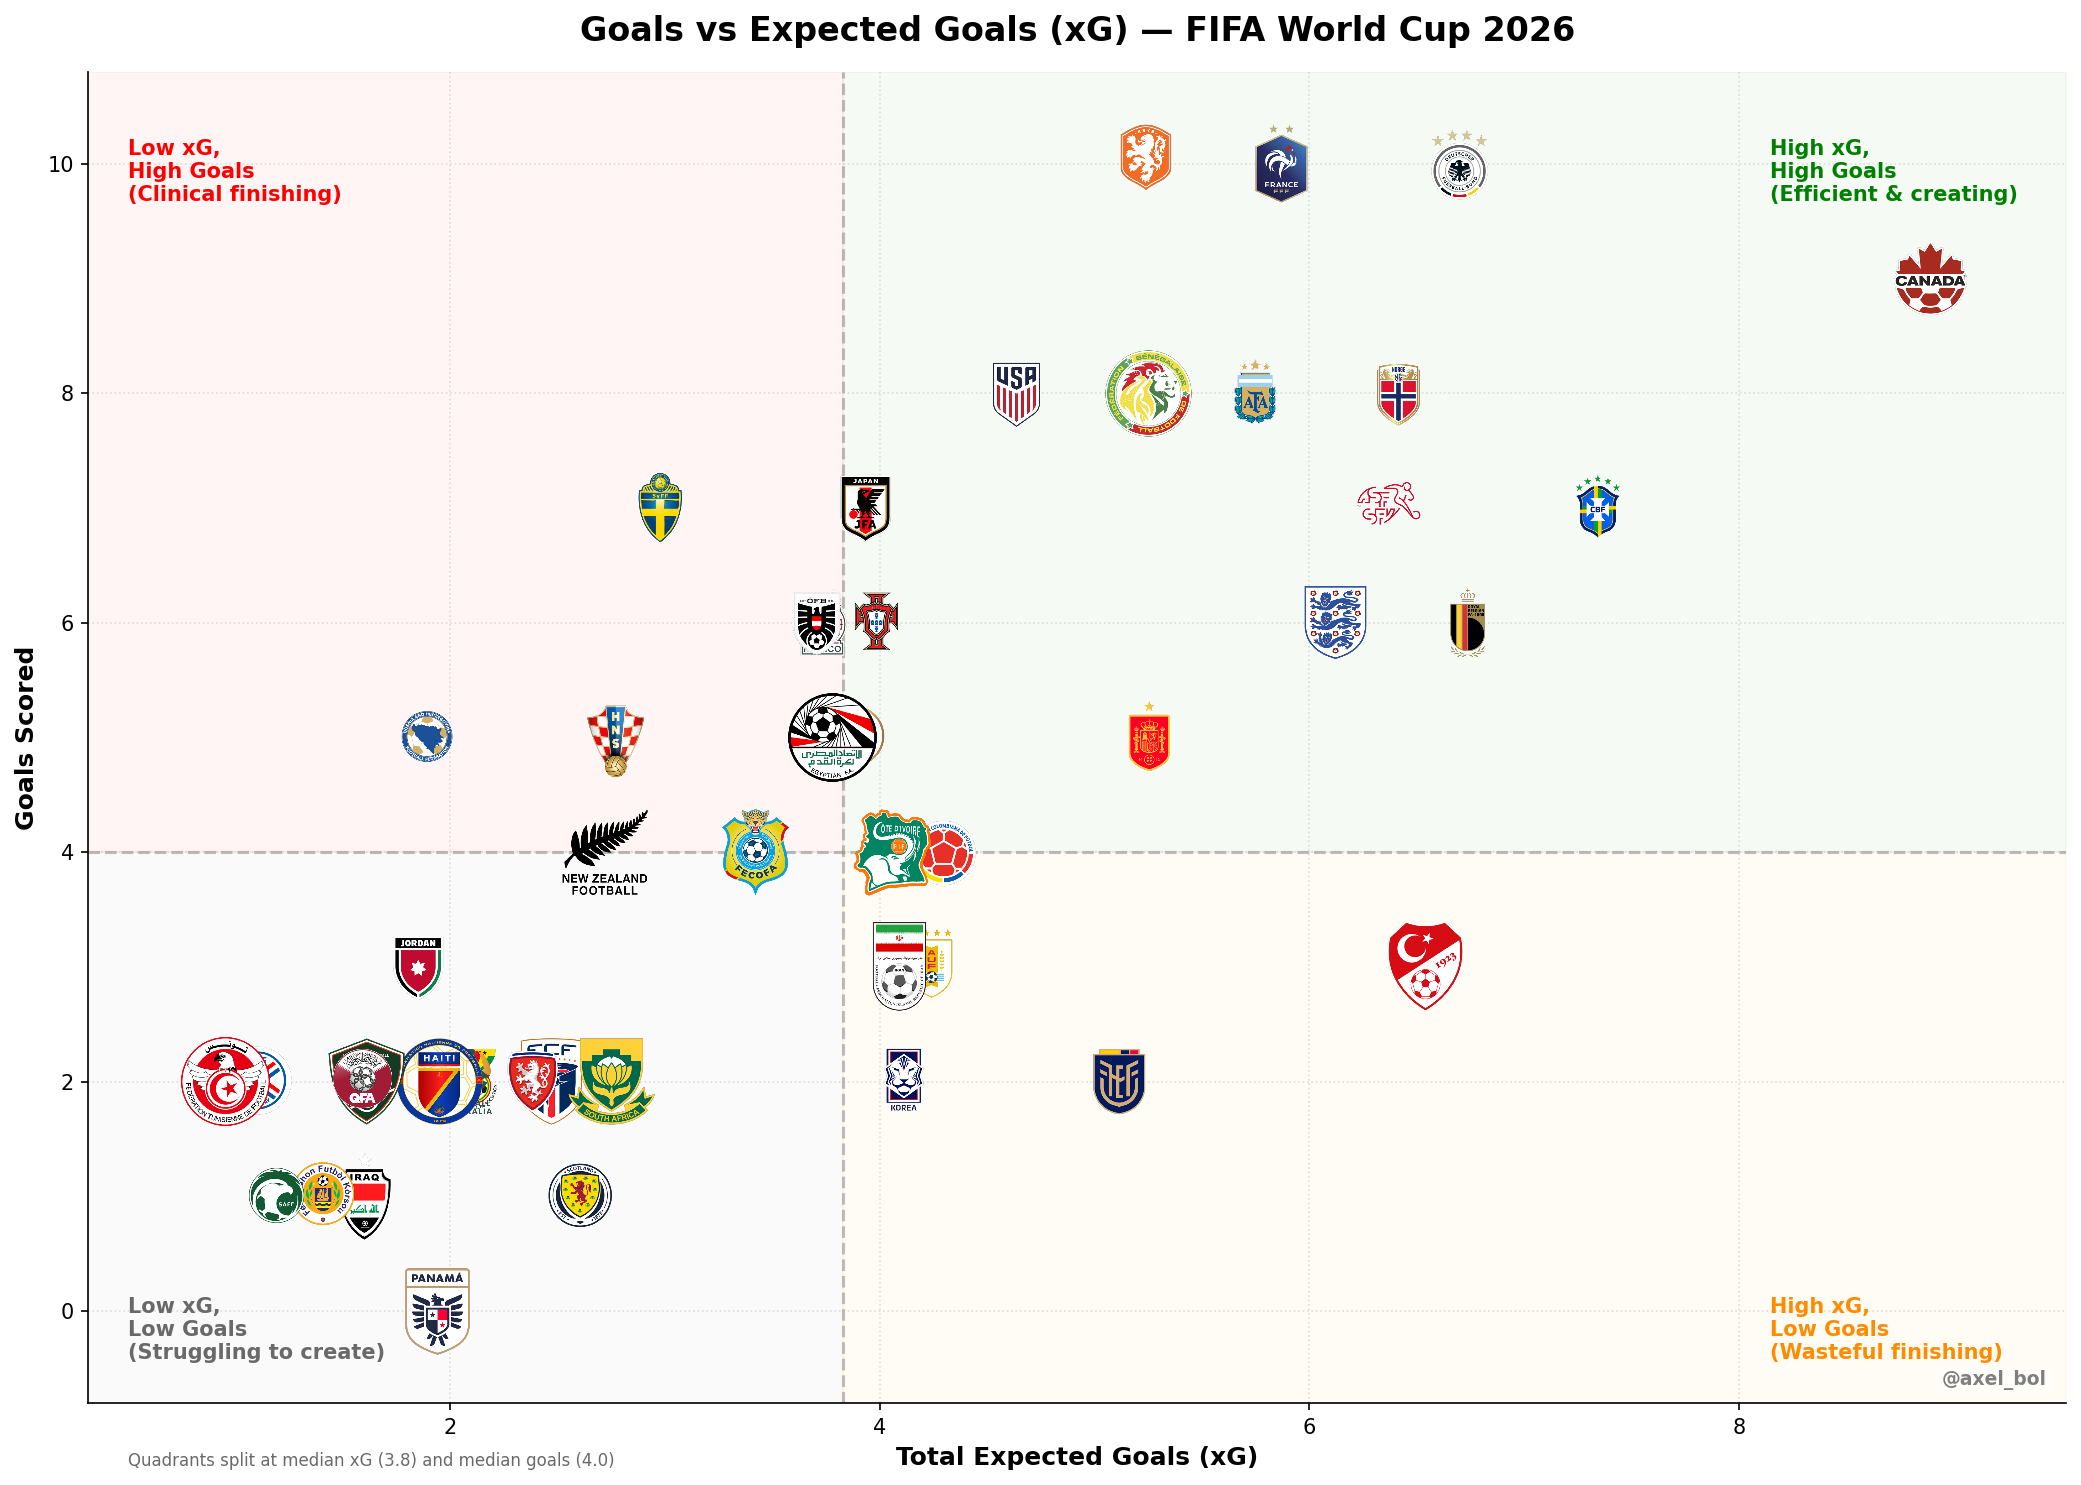

In [2]:
# fixed logos https://claude.ai/chat/be30b975-c978-47e6-93c7-e497c7f78a6e

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from PIL import Image
import numpy as np
import os

# --- Config ---
logo_folder = r"C:\Users\Public\Documents\Axel\team_logos"
LOGO_CANVAS = 250      # px, square canvas every logo gets normalized into
logo_zoom = 0.17       # now consistent across all logos since canvas size is fixed
annotation_size = 10
fig, ax = plt.subplots(figsize=(14, 10), dpi=150)

x = df['total_xG']
y = df['goals']
pad_x = (x.max() - x.min()) * 0.08
pad_y = (y.max() - y.min()) * 0.08
x_min, x_max = x.min() - pad_x, x.max() + pad_x
y_min, y_max = y.min() - pad_y, y.max() + pad_y

median_xg = x.median()
median_goals = y.median()
ax.axvline(median_xg, linestyle='--', color='gray', linewidth=1.5, alpha=0.5, zorder=1)
ax.axhline(median_goals, linestyle='--', color='gray', linewidth=1.5, alpha=0.5, zorder=1)

_logo_cache = {}

def get_logo(team_id, zoom=logo_zoom, canvas=LOGO_CANVAS):
    """Load a logo and paste it, aspect-ratio preserved, centered on a
    fixed-size transparent square canvas so every logo renders at the
    same visual size regardless of its native resolution/aspect ratio."""
    if team_id in _logo_cache:
        img_array = _logo_cache[team_id]
    else:
        path = os.path.join(logo_folder, f"{team_id}.png")
        img = Image.open(path).convert("RGBA")

        # Scale logo to fit inside the canvas while keeping aspect ratio
        scale = min(canvas / img.width, canvas / img.height)
        new_w, new_h = int(img.width * scale), int(img.height * scale)
        img_resized = img.resize((new_w, new_h), Image.LANCZOS)

        # Paste centered on transparent square canvas
        bg = Image.new("RGBA", (canvas, canvas), (0, 0, 0, 0))
        offset = ((canvas - new_w) // 2, (canvas - new_h) // 2)
        bg.paste(img_resized, offset, img_resized)

        img_array = np.array(bg)
        _logo_cache[team_id] = img_array

    return OffsetImage(img_array, zoom=zoom)

for _, row in df.iterrows():
    try:
        ab = AnnotationBbox(
            get_logo(row['teamId']),
            (row['total_xG'], row['goals']),
            frameon=False,
            zorder=3
        )
        ax.add_artist(ab)
    except FileNotFoundError:
        ax.scatter(row['total_xG'], row['goals'], color='green', s=20, zorder=3)
        ax.annotate(row['teamName'], (row['total_xG'], row['goals']), fontsize=6)

ax.fill_between([x_min, median_xg], median_goals, y_max, color='red', alpha=0.04, zorder=0)
ax.fill_between([median_xg, x_max], median_goals, y_max, color='green', alpha=0.04, zorder=0)
ax.fill_between([x_min, median_xg], y_min, median_goals, color='gray', alpha=0.04, zorder=0)
ax.fill_between([median_xg, x_max], y_min, median_goals, color='orange', alpha=0.04, zorder=0)

x_range = x_max - x_min
y_range = y_max - y_min

annotations = [
    dict(x=x_min + x_range*0.02, y=y_max - y_range*0.05,
         text="Low xG,\nHigh Goals\n(Clinical finishing)", color="red"),
    dict(x=x_max - x_range*0.15, y=y_max - y_range*0.05,
         text="High xG,\nHigh Goals\n(Efficient & creating)", color="green"),
    dict(x=x_min + x_range*0.02, y=y_min + y_range*0.08,
         text="Low xG,\nLow Goals\n(Struggling to create)", color="dimgray"),
    dict(x=x_max - x_range*0.15, y=y_min + y_range*0.08,
         text="High xG,\nLow Goals\n(Wasteful finishing)", color="darkorange"),
]

for ann in annotations:
    ax.text(ann['x'], ann['y'], ann['text'],
            fontsize=annotation_size, fontweight='bold',
            color=ann['color'], ha='left', va='top', zorder=4)

ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
ax.set_xlabel('Total Expected Goals (xG)', fontsize=12, fontweight='bold')
ax.set_ylabel('Goals Scored', fontsize=12, fontweight='bold')
ax.set_title('Goals vs Expected Goals (xG) — FIFA World Cup 2026', fontsize=16, fontweight='bold', pad=15)
ax.text(0.02, -0.05, f'Quadrants split at median xG ({median_xg:.1f}) and median goals ({median_goals:.1f})',
        transform=ax.transAxes, fontsize=8, va='bottom', color='dimgray',
        bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

# plt.text(8.5, -2, 'Data via Opta | @axel_bol', ha='center', fontsize=8, fontfamily='monospace')
# --- X (Twitter) credit, bottom right ---
ax.text(0.99, 0.01, '@axel_bol', transform=ax.transAxes,
        fontsize=9, fontweight='bold', color='dimgray',
        ha='right', va='bottom', alpha=0.85,
        bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', pad=2))

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(True, linestyle=':', alpha=0.4)

plt.tight_layout()
# plt.savefig(r'C:\Users\Public\Documents\Axel\images\xG_Goals_logos_updated.png', dpi=300, bbox_inches='tight', pad_inches=0.35)
plt.show()

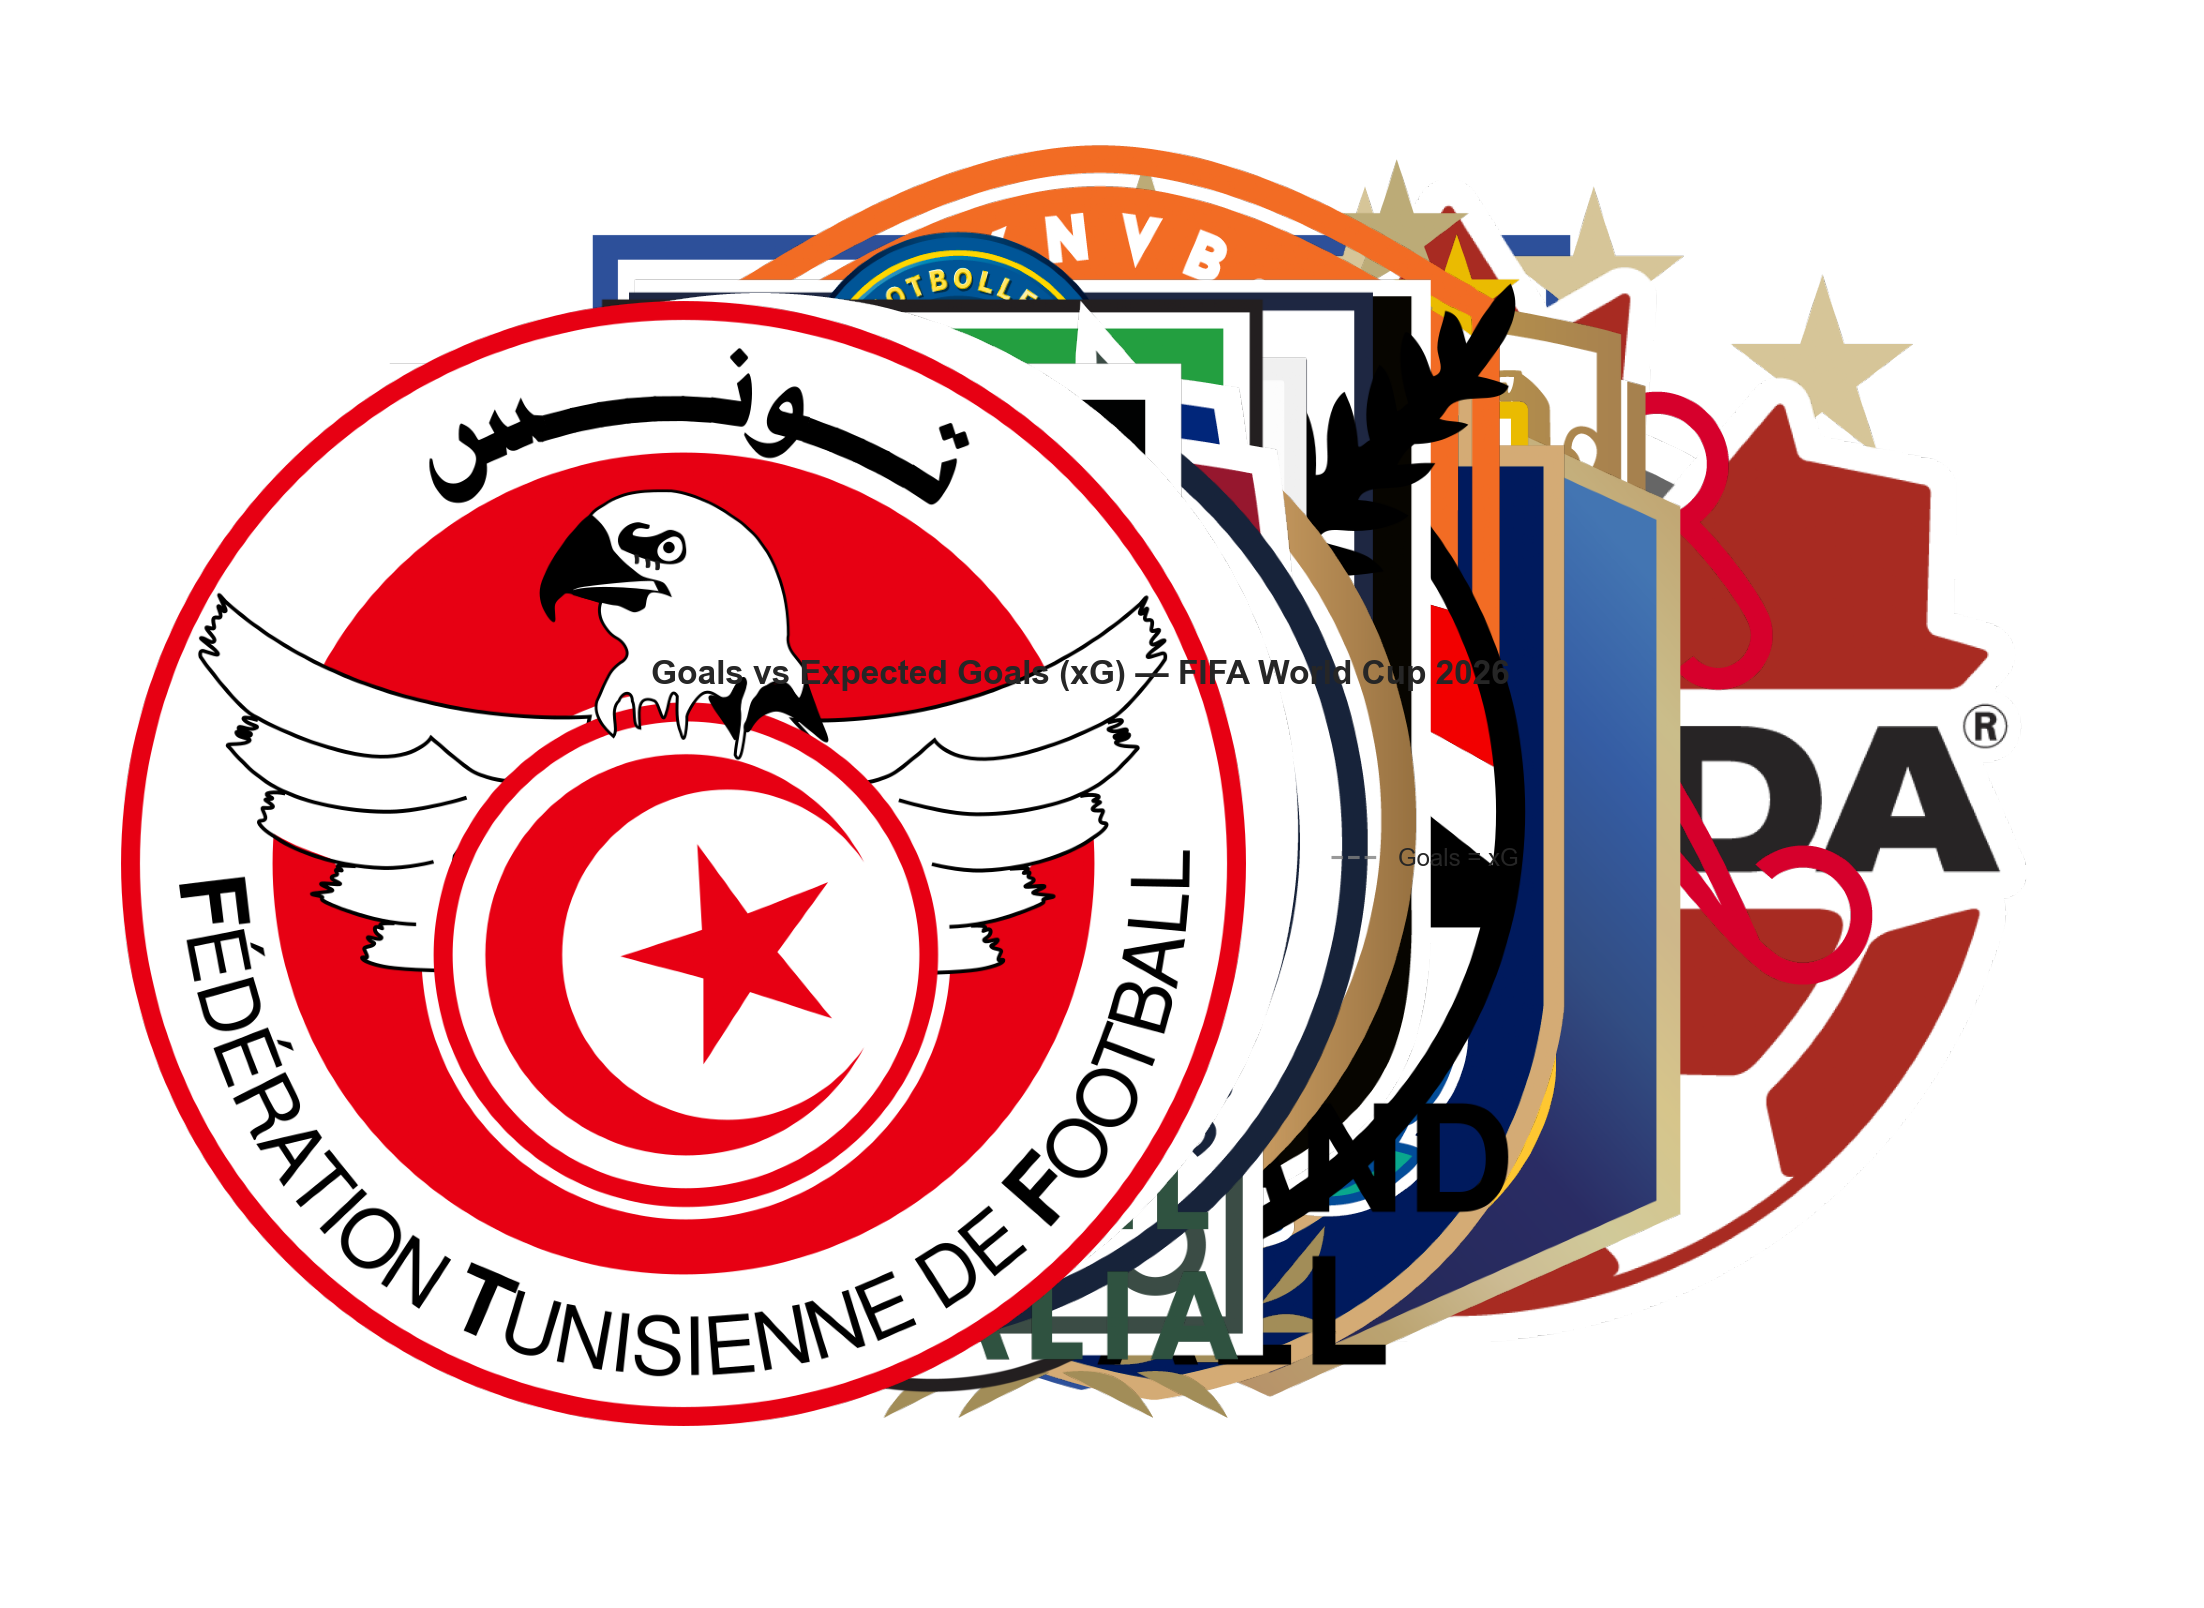

In [ ]:
# Claude Seaborn with team logos https://claude.ai/chat/50421c8d-d5ca-4a39-b6ec-0df23783800f

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import os

sns.set_theme(style="whitegrid", font_scale=1.05)

logo_folder = r"C:\Users\Public\Documents\Axel\team_logos"
logo_zoom = 0.45

fig, ax = plt.subplots(figsize=(14, 10), dpi=150)

x = df['total_xG']
y = df['goals']
pad_x = (x.max() - x.min()) * 0.08
pad_y = (y.max() - y.min()) * 0.08
x_min, x_max = x.min() - pad_x, x.max() + pad_x
y_min, y_max = y.min() - pad_y, y.max() + pad_y
lims = [min(x_min, y_min), max(x_max, y_max)]

# Invisible scatter just so seaborn sets up a nice themed axis/grid first
sns.scatterplot(data=df, x='total_xG', y='goals', alpha=0, ax=ax)

ax.plot(lims, lims, linestyle='--', color='gray', linewidth=1.5, alpha=0.8, zorder=1, label='Goals = xG')

def get_logo(team_id, zoom=logo_zoom):
    path = os.path.join(logo_folder, f"{team_id}.png")
    img = mpimg.imread(path)
    return OffsetImage(img, zoom=zoom)

for _, row in df.iterrows():
    try:
        ab = AnnotationBbox(get_logo(row['teamId']), (row['total_xG'], row['goals']),
                             frameon=False, zorder=3)
        ax.add_artist(ab)
    except FileNotFoundError:
        sns.scatterplot(x=[row['total_xG']], y=[row['goals']], color='red', s=30, ax=ax, zorder=3)

ax.fill_between(lims, lims, y_max, color='seagreen', alpha=0.05, zorder=0)
ax.fill_between(lims, y_min, lims, color='firebrick', alpha=0.05, zorder=0)

ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
ax.set_xlabel('Total Expected Goals (xG)', fontweight='bold')
ax.set_ylabel('Goals Scored', fontweight='bold')
ax.set_title('Goals vs Expected Goals (xG) — FIFA World Cup 2026', fontsize=16, fontweight='bold', pad=15)
sns.despine()
ax.legend(loc='lower right', frameon=False)

plt.tight_layout()
# plt.savefig('goals_vs_xg_worldcup2026_seaborn.png', dpi=300, bbox_inches='tight')
plt.show()

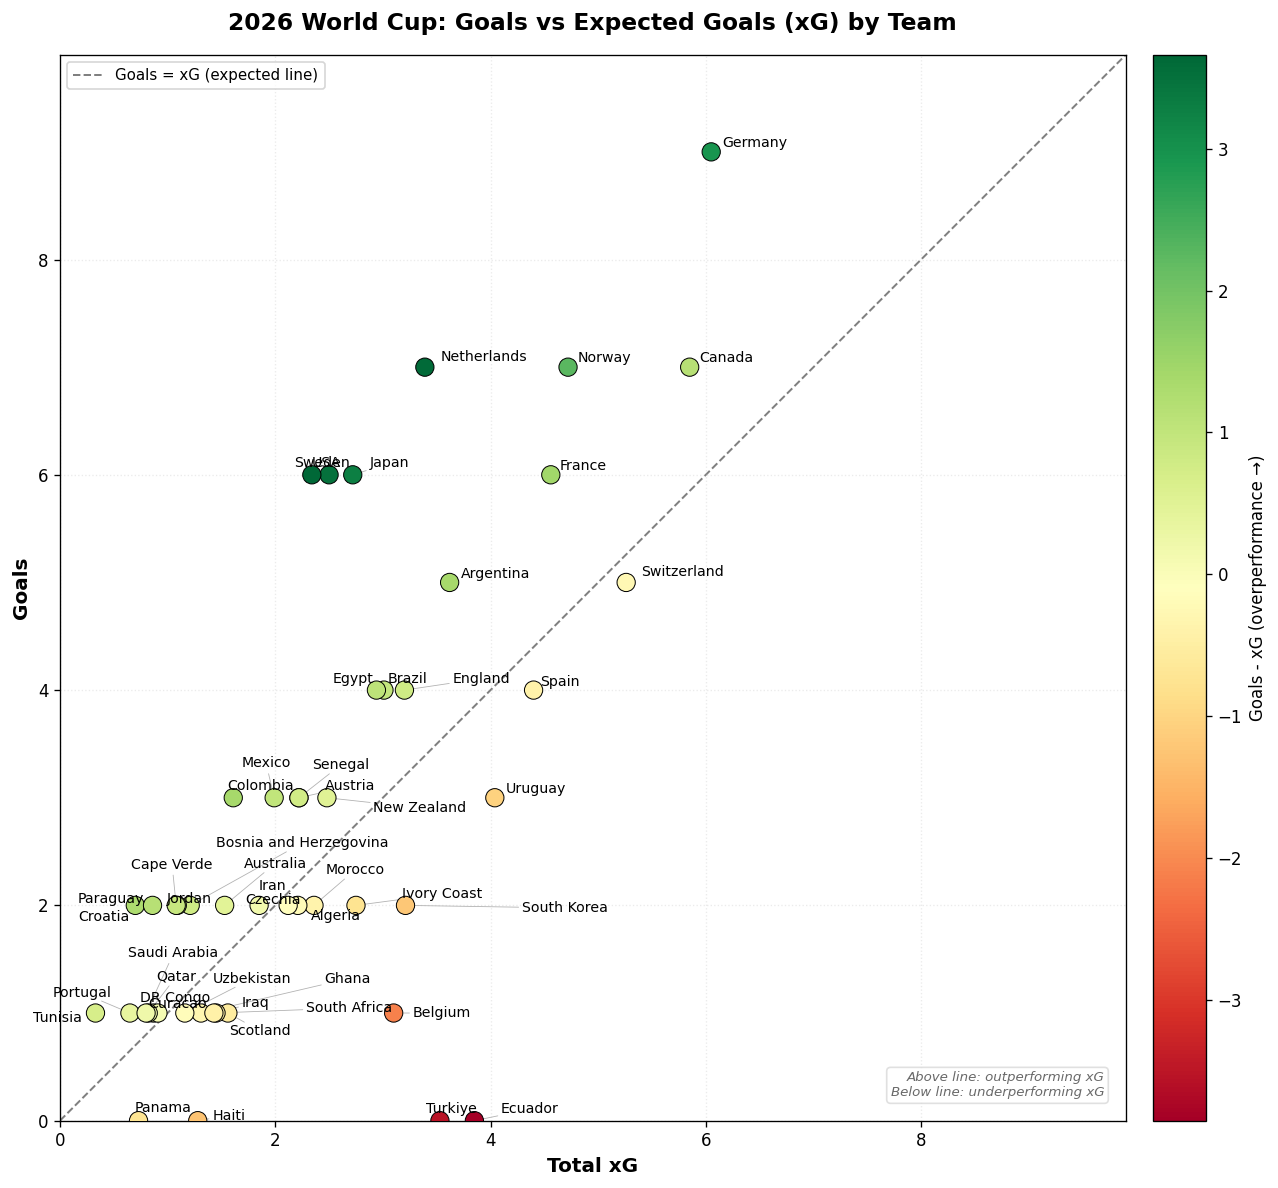

In [21]:
import matplotlib.pyplot as plt
import numpy as np
from adjustText import adjust_text

fig, ax = plt.subplots(figsize=(12, 10), dpi=120)

# Compute over/underperformance for coloring
df['xG_diff'] = df['goals'] - df['total_xG']

# Diagonal reference line (y = x) — defines "performed as expected"
max_val = max(df['goals'].max(), df['total_xG'].max()) * 1.1
min_val = 0
ax.plot([min_val, max_val], [min_val, max_val],
        linestyle='--', color='gray', linewidth=1.2, zorder=1,
        label='Goals = xG (expected line)')

# Scatter, colored by over/underperformance
scatter = ax.scatter(
    df['total_xG'], df['goals'],
    c=df['xG_diff'], cmap='RdYlGn', s=120,
    edgecolors='black', linewidth=0.6, zorder=3
)

# Colorbar to explain the color coding
cbar = plt.colorbar(scatter, ax=ax, pad=0.02)
cbar.set_label('Goals - xG (overperformance →)', fontsize=10)

# Team name labels, auto-adjusted to avoid overlap
texts = []
for _, row in df.iterrows():
    texts.append(
        ax.text(row['total_xG'], row['goals'], row['teamName'],
                fontsize=8.5, zorder=4)
    )
adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle='-', color='gray', lw=0.5, alpha=0.6))

ax.set_xlim(min_val, max_val)
ax.set_ylim(min_val, max_val)
ax.set_xlabel('Total xG', fontsize=12, fontweight='bold')
ax.set_ylabel('Goals', fontsize=12, fontweight='bold')
ax.set_title('2026 World Cup: Goals vs Expected Goals (xG) by Team',
             fontsize=14, fontweight='bold', pad=15)
ax.set_aspect('equal', adjustable='box')
ax.grid(alpha=0.25, linestyle=':')
ax.legend(loc='upper left', fontsize=9, frameon=True)

# Subtle annotation explaining the diagonal
ax.text(0.98, 0.02, 'Above line: outperforming xG\nBelow line: underperforming xG',
        transform=ax.transAxes, fontsize=8, ha='right', va='bottom',
        style='italic', color='dimgray',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.7, edgecolor='lightgray'))

plt.tight_layout()
plt.savefig('goals_vs_xg_matplotlib.png', dpi=150, bbox_inches='tight')
plt.show()

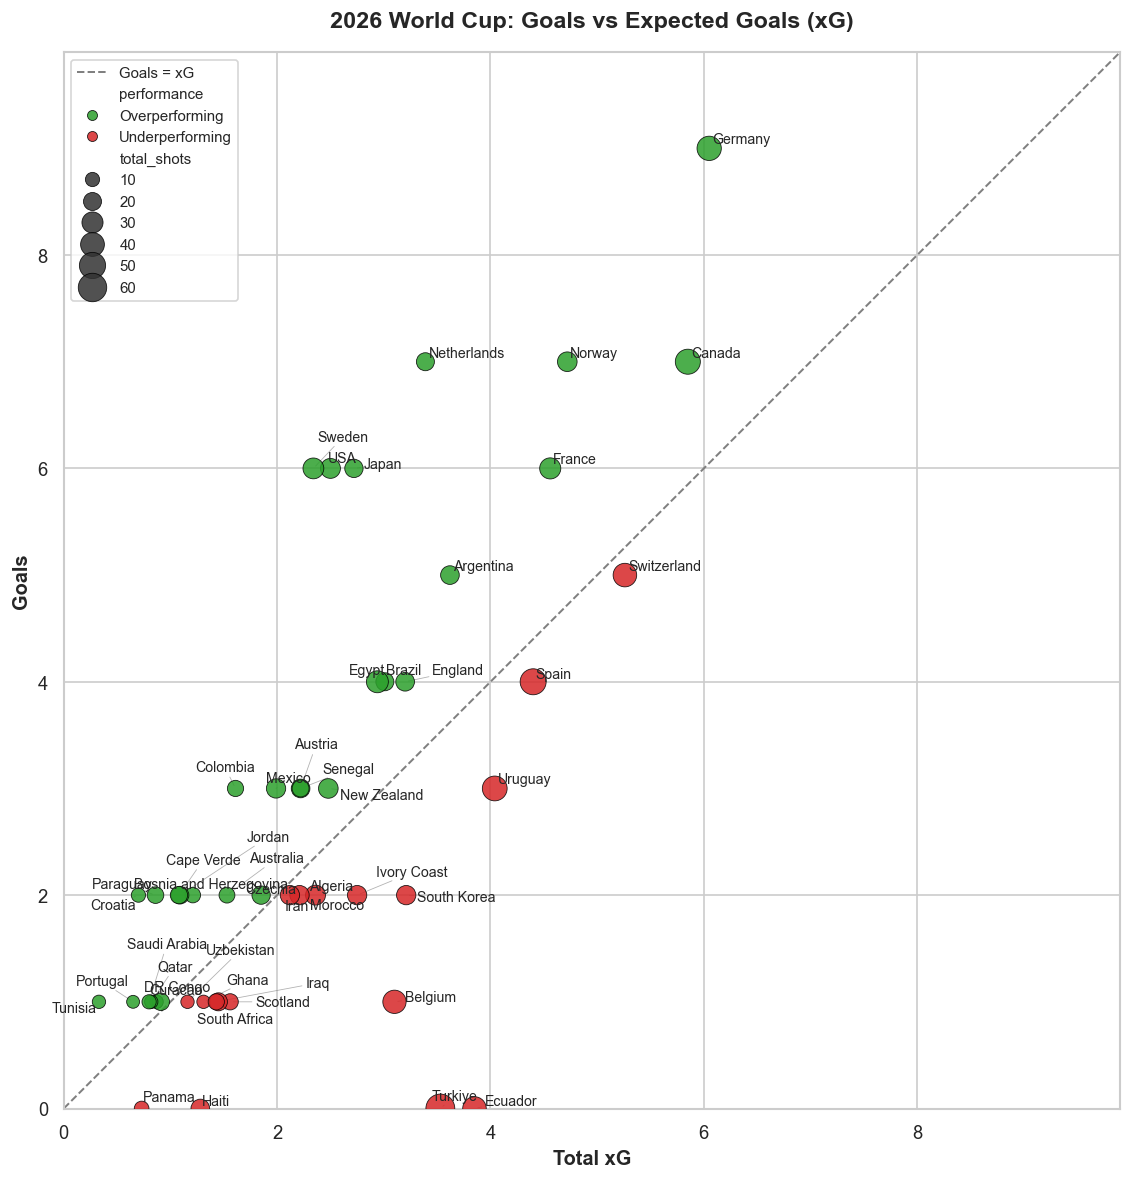

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt
from adjustText import adjust_text

sns.set_theme(style='whitegrid', font_scale=1.0)

df['xG_diff'] = df['goals'] - df['total_xG']
df['performance'] = np.where(df['xG_diff'] >= 0, 'Overperforming', 'Underperforming')

fig, ax = plt.subplots(figsize=(12, 10), dpi=120)

max_val = max(df['goals'].max(), df['total_xG'].max()) * 1.1

# Diagonal reference line
ax.plot([0, max_val], [0, max_val],
        linestyle='--', color='gray', linewidth=1.2, zorder=1,
        label='Goals = xG')

# Seaborn scatterplot, sized by total_shots if you want an extra dimension
sns.scatterplot(
    data=df, x='total_xG', y='goals',
    hue='performance', palette={'Overperforming': '#2ca02c', 'Underperforming': '#d62728'},
    size='total_shots', sizes=(60, 300), alpha=0.85,
    edgecolor='black', linewidth=0.5, ax=ax, zorder=3
)

# Labels with adjustText to dodge overlaps
texts = [
    ax.text(row['total_xG'], row['goals'], row['teamName'], fontsize=8.5, zorder=4)
    for _, row in df.iterrows()
]
adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle='-', color='gray', lw=0.5, alpha=0.6))

ax.set_xlim(0, max_val)
ax.set_ylim(0, max_val)
ax.set_aspect('equal', adjustable='box')
ax.set_xlabel('Total xG', fontsize=12, fontweight='bold')
ax.set_ylabel('Goals', fontsize=12, fontweight='bold')
ax.set_title('2026 World Cup: Goals vs Expected Goals (xG)',
             fontsize=14, fontweight='bold', pad=15)
ax.legend(title='', loc='upper left', fontsize=9, frameon=True)

plt.tight_layout()
plt.savefig('goals_vs_xg_seaborn.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
import plotly.express as px

df['xG_diff'] = df['goals'] - df['total_xG']

fig = px.scatter(
    df, x='total_xG', y='goals', text='teamName',
    color='xG_diff', color_continuous_scale='RdYlGn',
    hover_data=['matches', 'total_shots', 'big_chances'],
    title='2026 World Cup: Goals vs xG'
)

max_val = max(df['goals'].max(), df['total_xG'].max()) * 1.1
fig.add_shape(type='line', x0=0, y0=0, x1=max_val, y1=max_val,
              line=dict(dash='dash', color='gray'))

fig.update_traces(textposition='top center', textfont_size=8, marker=dict(size=10))
fig.update_layout(xaxis_range=[0, max_val], yaxis_range=[0, max_val], width=900, height=900)
fig.show()